# Comparing Model Performance with a Simple Baseline
This notebook focuses on comparing the generalization performance of a model to a minimal baseline, such as the `DummyRegressor`.

In [1]:
from sklearn.datasets import fetch_california_housing

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100

In [2]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(
    n_splits=30,
    test_size=0.2,
    random_state=0
)

In [11]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate

regressor = DecisionTreeRegressor()
cv_results_tree = cross_validate(
    regressor,
    data,
    target,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=2
)

errors_tree = pd.Series(
    -cv_results_tree["test_score"], name="Decision Tree Regressor"
)

errors_tree.describe()

count    30.000000
mean     45.686178
std       1.237510
min      43.055855
25%      44.883176
50%      45.561401
75%      46.590979
max      48.212253
Name: Decision Tree Regressor, dtype: float64

This has provided the errors from the cross-validation of 30 splits where 20% of the data has been held out. We can now compare to our baseline `DummyRegressor`, which will always predict the mean target computed on the training target variable.

In [12]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
result_dummy = cross_validate(
    dummy,
    data,
    target,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=2
)

errors_dummy = pd.Series(
    -result_dummy["test_score"], name="Dummy regressor"
)

errors_dummy.describe()

count    30.000000
mean     91.140009
std       0.821140
min      89.757566
25%      90.543652
50%      91.034555
75%      91.979007
max      92.477244
Name: Dummy regressor, dtype: float64

In [13]:
all_errors = pd.concat(
    [errors_tree, errors_dummy],
    axis=1,
)
all_errors

,Decision Tree Regressor,Dummy regressor
0,46.648926,90.713153
1,46.709276,90.539353
2,44.845756,91.941912
3,43.809998,90.213912
4,47.877492,92.015862
5,44.995436,90.542490
6,43.897666,89.757566
7,44.806366,92.477244
8,45.240590,90.947952
9,44.586085,91.991373


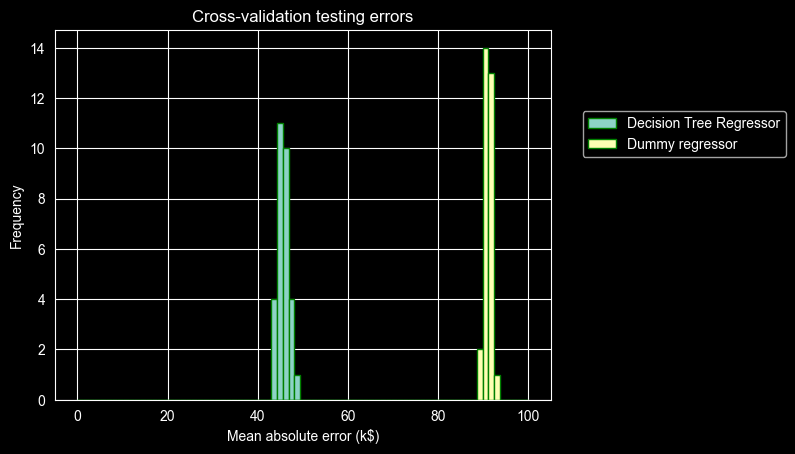

In [14]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(start=0, stop=100, num=80)
all_errors.plot.hist(bins=bins, edgecolor="green")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Mean absolute error (k$)")
_ = plt.title("Cross-validation testing errors")

As can be seen, the generalization performance of the decision tree is far from perfect, and is on average off by more than $45,000. However, it is better than the baseline.

Finally, we measure the test score using $R^2$ instead of the mean absolute error.

In [15]:
result_dummy = cross_validate(
    dummy, data, target, cv=cv, scoring="r2", return_train_score=True, n_jobs=2
)
r2_train_score_dummy_regressor = pd.Series(
    result_dummy["train_score"], name="Dummy regressor train score"
)
r2_train_score_dummy_regressor.describe()

count    30.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: Dummy regressor train score, dtype: float64

The $R^2$ is always 0, as the dummy always predicts the mean. That said, if the model has $R^2$ higher than 0, then it performs better than a `DummyRegressor` with  `strategy="mean"`; the opposite is true when $R^2$ is less than 0.

In [16]:
r2_test_score_dummy_regressor = pd.Series(
    result_dummy["test_score"], name="Dummy regressor test score"
)
r2_test_score_dummy_regressor.describe()

count    3.000000e+01
mean    -2.203750e-04
std      3.572610e-04
min     -1.797131e-03
25%     -2.753534e-04
50%     -1.083489e-04
75%     -3.344120e-05
max     -1.015390e-07
Name: Dummy regressor test score, dtype: float64